# Carga de datos

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))
from scripts.data.load_data import cargar_raw
df=cargar_raw("titanic_dataset.csv")
df.head()

#print(Path(__file__).resolve().parents) Usar cuando necesite conocer la ruta de un archivo.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Visión general de dataset


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.memory_usage().sum()

85668

In [5]:
df.duplicated().sum()

0

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [9]:
import pandas as pd

porcentaje_nulos= pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": df.isna().sum()/len(df)*100
}).sort_values("Porcentaje", ascending=False)

porcentaje_nulos.round(2)

,Nulos,Porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
SibSp,0,0.00
Parch,0,0.00


In [10]:
ratio_unicos= pd.DataFrame({
    "Unicos": df.nunique(),
    "Ratio": df.nunique()/len(df)
})

ratio_unicos.round(2)

,Unicos,Ratio
PassengerId,891,1.00
Survived,2,0.00
Pclass,3,0.00
Name,891,1.00
Sex,2,0.00
Age,88,0.10
SibSp,7,0.01
Parch,7,0.01
Ticket,681,0.76
Fare,248,0.28


# Análisis por variable

## Validación

In [11]:
# Importar librerías para visualizar

import matplotlib.pyplot as plt
import seaborn as sns

## ID

In [12]:
#PassengerId validación

resumen_passenger_id = pd.Series({
    "tipo": df["PassengerId"].dtype,
    "duplicados": df["PassengerId"].duplicated().sum(),
    "nulos": df["PassengerId"].isna().sum(),
    "max": df["PassengerId"].max(),
    "min": df["PassengerId"].min(),
    "longitud": df["PassengerId"].astype(str).str.len().value_counts()
})

resumen_passenger_id

tipo                                                      int64
duplicados                                                    0
nulos                                                         0
max                                                         891
min                                                           1
longitud      PassengerId
3    792
2     90
1      9
Name: c...
dtype: object

In [13]:
#Convertir PassengerId a string

df["PassengerId"] = df["PassengerId"].astype(str)
df["PassengerId"].dtype

dtype('O')

## Tarjet

In [14]:
# Survived validación

resumen_survived = pd.Series({
    "tipo": df["Survived"].dtype,
    "nulos": df["Survived"].isna().sum(),
    "valores unicos": df["Survived"].unique(),
    "conteo valores unicos": df["Survived"].value_counts()
})

resumen_survived

tipo                                                                 int64
nulos                                                                    0
valores unicos                                                      [0, 1]
conteo valores unicos    Survived
0    549
1    342
Name: count, dtype:...
dtype: object

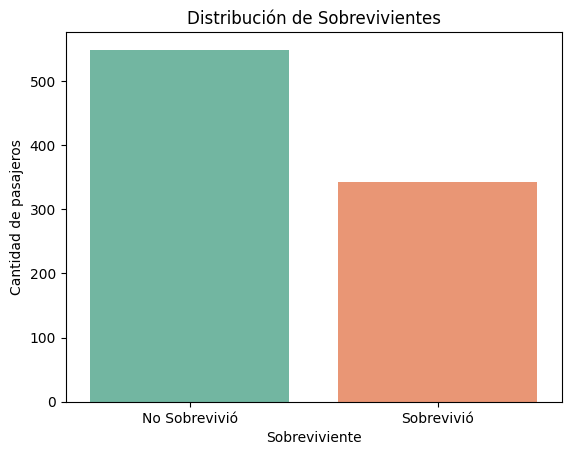

Survived
0    62.0
1    38.0
Name: proportion, dtype: float64

In [15]:
# Visualización de Survived

sobrevivientes = df['Survived'].value_counts(normalize=True)

sns.countplot(
    data=df,
    x='Survived',
    palette='Set2')

plt.title('Distribución de Sobrevivientes')
plt.xlabel('Sobreviviente')
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0, 1], labels=['No Sobrevivió', 'Sobrevivió'])
plt.show()

round(sobrevivientes, 2)*100



## Variables categóricas

In [16]:
# Variables categoricas sex embarked y Pclass validación

resumen_pclass = pd.Series({
    "tipo": df["Pclass"].dtype,
    "nulos": df["Pclass"].isna().sum(),
    "valores unicos": df["Pclass"].nunique(),
    "conteo valores unicos": df["Pclass"].value_counts()

})
resumen_pclass


tipo                                                                 int64
nulos                                                                    0
valores unicos                                                           3
conteo valores unicos    Pclass
3    491
1    216
2    184
Name: count,...
dtype: object

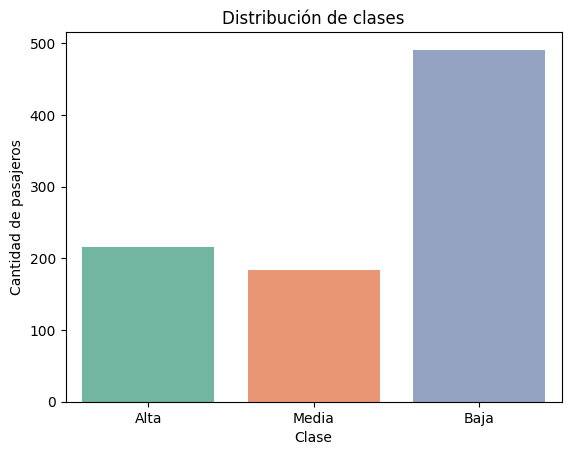

Pclass
3    55.0
1    24.0
2    21.0
Name: proportion, dtype: float64

In [17]:
# Visualización univariada de Pclass

sns.countplot(
    data=df,
    x="Pclass",
    palette="Set2")

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()

df["Pclass"].value_counts(normalize=True).round(2)*100

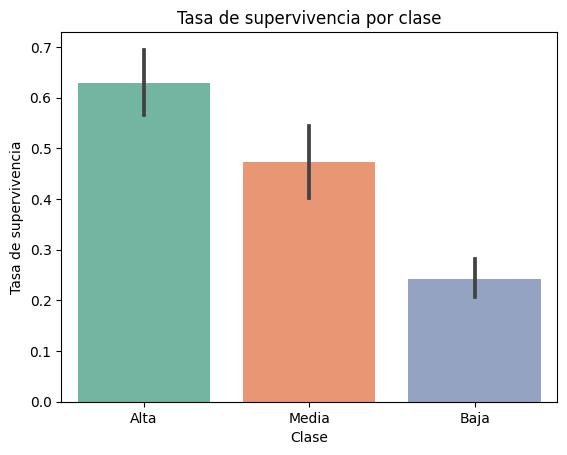

In [18]:
# Visualización bivariada de Pclass y Survived

sns.barplot(
    data=df,
    x="Pclass", 
    y="Survived", 
    palette="Set2")

plt.title("Tasa de supervivencia por clase")
plt.xlabel("Clase") 
plt.ylabel("Tasa de supervivencia")
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()




In [19]:
# Relación entre Pclass y Survived con diff y crosstab

tasa_ps=df.groupby("Pclass")["Survived"].mean().round(2) * 100
diff = tasa_ps.max() - tasa_ps.min()
print(f"Diferencia en tasa de supervivencia entre clases: {diff}%")

crosstab_ps = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_ps.round(2))

Diferencia en tasa de supervivencia entre clases: 39.0%
Tabla de contingencia (normalizada por fila):
Survived      0      1
Pclass                
1         37.04  62.96
2         52.72  47.28
3         75.76  24.24


In [20]:
# Validación de sex

resumen_sex= pd.Series({
    "tipo": df["Sex"].dtype,
    "nulos  ": df["Sex"].isna().sum(),
    "valores unicos": df["Sex"].nunique(),
    "conteo valores unicos": df["Sex"].value_counts()
})

resumen_sex

tipo                                                                object
nulos                                                                    0
valores unicos                                                           2
conteo valores unicos    Sex
male      577
female    314
Name: count, d...
dtype: object

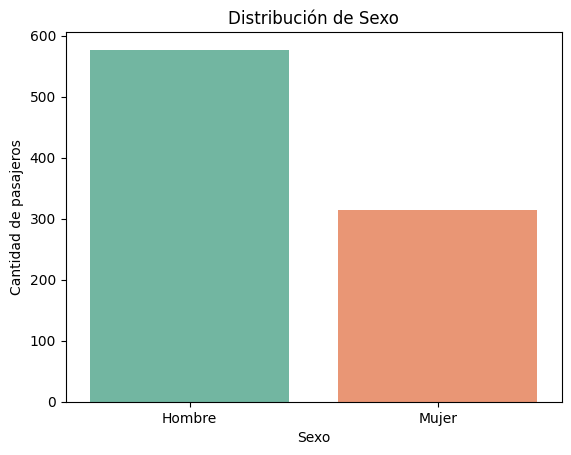

Sex
male      65.0
female    35.0
Name: proportion, dtype: float64

In [21]:
# Visualización univariada de Sex

sns.countplot(
    data=df, 
    x="Sex",
    palette="Set2")

plt.title('Distribución de Sexo')
plt.xlabel('Sexo')  
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0,1], labels=['Hombre', 'Mujer'])  
plt.show()

df["Sex"].value_counts(normalize=True).round(2)*100

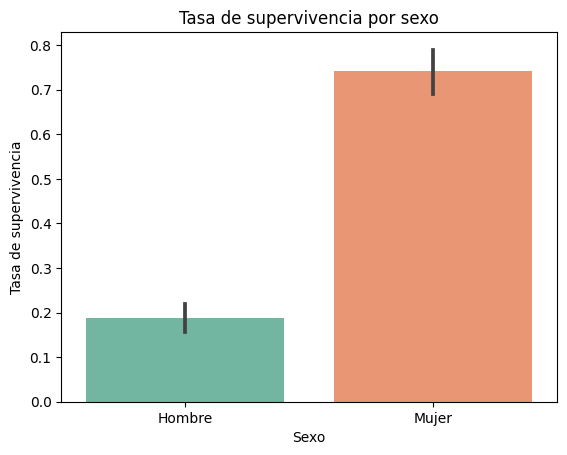

In [22]:
#Visualización bivariada de Sex y Survived

sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    palette="Set2")

plt.title('Tasa de supervivencia por sexo')
plt.xlabel('Sexo')  
plt.ylabel('Tasa de supervivencia')
plt.xticks(ticks=[0,1], labels=['Hombre', 'Mujer'])  
plt.show()



In [23]:
# Relación entre Sex y Survived con diff y crosstab

tasa_ss=df.groupby("Sex")["Survived"].mean().round(2)*100
diff = tasa_ss.max() - tasa_ss.min()
print(f"Diferencia en tasa de supervivencia entre hombres y mujeres: {diff}%")

crosstab_ss = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_ss.round(2))

Diferencia en tasa de supervivencia entre hombres y mujeres: 55.0%
Tabla de contingencia (normalizada por fila):
Survived      0      1
Sex                   
female    25.80  74.20
male      81.11  18.89


In [24]:
# Validación de Embarked

resumen_embarked = pd.Series({
    "tipo": df["Embarked"].dtype,
    "nulos": df["Embarked"].isna().sum(),
    "valores unicos": df["Embarked"].nunique(),
    "conteo valores unicos": df["Embarked"].value_counts()
})

resumen_embarked

tipo                                                                object
nulos                                                                    2
valores unicos                                                           3
conteo valores unicos    Embarked
S    644
C    168
Q     77
Name: coun...
dtype: object

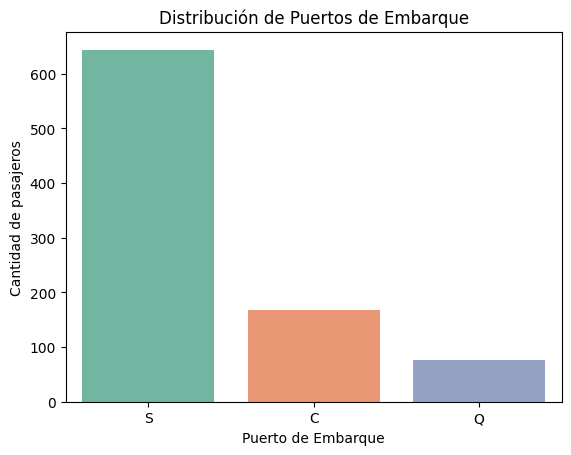

Embarked
S    72.0
C    19.0
Q     9.0
Name: proportion, dtype: float64

In [25]:
# Visualización univariada de Embarked

sns.countplot(
    data=df,
    x="Embarked",
    palette="Set2")

plt.title('Distribución de Puertos de Embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Cantidad de pasajeros')
plt.show()

df["Embarked"].value_counts(normalize=True).round(2)*100

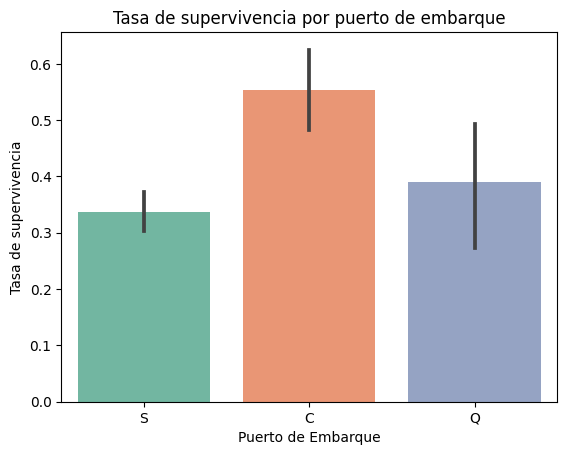

In [26]:
# Visualización bivariada de Embarked y Survived

sns.barplot(
    data=df,
    x="Embarked",
    y="Survived",
    palette="Set2")

plt.title('Tasa de supervivencia por puerto de embarque')
plt.xlabel('Puerto de Embarque')
plt.ylabel('Tasa de supervivencia')
plt.show()


In [27]:
# Relación entre Embarked y Survived con diff y crosstab

tasa_es=df.groupby("Embarked")["Survived"].mean().round(2)*100
diff_embarked = tasa_es.max() - tasa_es.min()
print(f"Diferencia en tasa de supervivencia entre puertos de embarque: {diff_embarked}%")

crosstab_es = pd.crosstab(df["Embarked"], df["Survived"], normalize="index") * 100
print(f"Tabla de contingencia (normalizada por fila):")
print(crosstab_es.round(2))

Diferencia en tasa de supervivencia entre puertos de embarque: 21.000000000000007%
Tabla de contingencia (normalizada por fila):
Survived      0      1
Embarked              
C         44.64  55.36
Q         61.04  38.96
S         66.30  33.70


In [28]:
# Viabilidad de interacción Sex y Pclass

print(df.groupby(['Sex', 'Pclass'])['Survived'].mean())
print(df.groupby(['Sex', 'Pclass'])['Survived'].size())

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64
Sex     Pclass
female  1          94
        2          76
        3         144
male    1         122
        2         108
        3         347
Name: Survived, dtype: int64


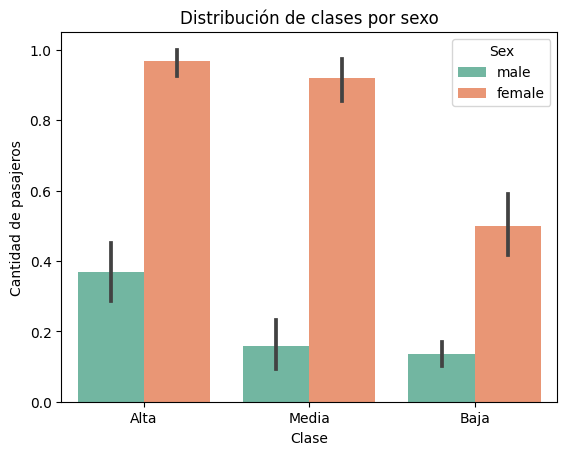

In [29]:
# Visualización multivariada de Pclass, Sex y Survived

sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    palette="Set2")

plt.title('Distribución de clases por sexo')
plt.xlabel('Clase') 
plt.ylabel('Cantidad de pasajeros')
plt.xticks(ticks=[0,1,2], labels=["Alta", "Media", "Baja"])
plt.show()



In [30]:
print(df.groupby(['Pclass', 'Embarked'])['Survived'].mean()*100)
print(df.groupby(['Embarked', 'Pclass'])['Survived'].size())

Pclass  Embarked
1       C           69.411765
        Q           50.000000
        S           58.267717
2       C           52.941176
        Q           66.666667
        S           46.341463
3       C           37.878788
        Q           37.500000
        S           18.980170
Name: Survived, dtype: float64
Embarked  Pclass
C         1          85
          2          17
          3          66
Q         1           2
          2           3
          3          72
S         1         127
          2         164
          3         353
Name: Survived, dtype: int64


## Variables numéricas

In [ ]:
# Validación Variables numéricas Age, SibSp, Parch y Fare
def resumen_numericas (df, col):
    data = df[col]
    
    resumen = {
        "variable": col,
        "dtype": data.dtype,
        "n": data.shape[0],
        "nulos": data.isna().sum(),
        "pct_nulos": round(data.isna().mean() * 100, 2),
        "min": data.min(),
        "max": data.max(),
        "media": data.mean(),
        "mediana": data.median(),
        "std": data.std(),
        "sesgo": (data.mean() - data.median())/data.std(),
        "cv": data.std()/data.mean(),
        "var": data.var(),
        "skewness": data.skew(),
        "kurtosis": data.kurt(),
        "quantiles": data.quantile([0.25, 0.5, 0.75]).to_dict(),
        "iqr": data.quantile(0.75) - data.quantile(0.25),
        "iqr relativo": (data.quantile(0.75) - data.quantile(0.25))/data.median(),
        "outliers LS": data.quantile(0.75) + 1.5 * (data.quantile(0.75) - data.quantile(0.25)),
        "outliers LI": data.quantile(0.25) - 1.5 * (data.quantile(0.75) - data.quantile(0.25))
    }
    
    return pd.DataFrame([resumen])


In [ ]:
# Age validación

resumen_numericas(df, 'Age')

,variable,dtype,n,nulos,pct_nulos,min,max,media,mediana,std,sesgo,cv,var,skewness,kurtosis,quantiles,iqr,iqr relativo,outliers LS,outliers LI
0,Age,float64,891,177,19.87,0.42,80.0,29.699118,28.0,14.526497,0.116967,0.489122,211.019125,0.389108,0.178274,"{0.25: 20.125, 0.5: 28.0, 0.75: 38.0}",17.875,0.638393,64.8125,-6.6875


C:\Users\ERIKA PINCHAO\AppData\Local\Temp\ipykernel_17168\2951429254.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Age'], kde=True, bins=30, palette="Set2")


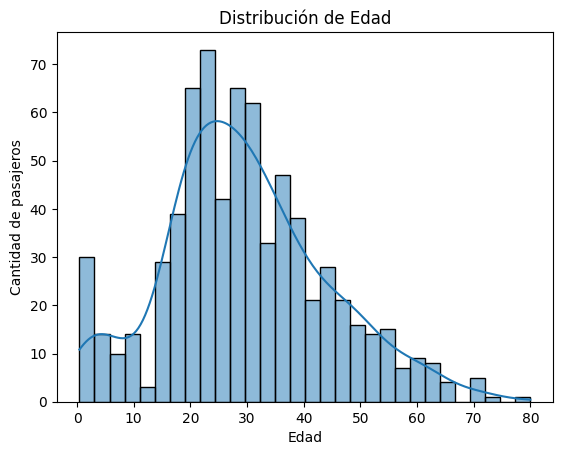

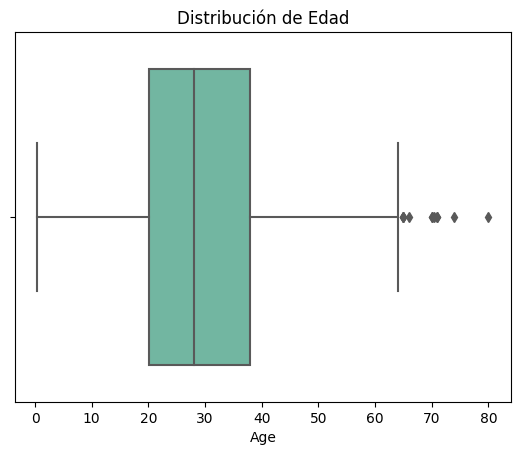

In [33]:
sns.histplot(df['Age'], kde=True, bins=30, palette="Set2")
plt.title('Distribución de Edad')   
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.show()

sns.boxplot(x=df['Age'], palette="Set2")
plt.title('Distribución de Edad') 
plt.show()

In [38]:
# Fare validación

resumen_numericas(df, 'Fare')

,variable,dtype,n,nulos,pct_nulos,min,max,media,mediana,std,sesgo,cv,var,skewness,kurtosis,quantiles,iqr,iqr relativo,outliers LS,outliers LI
0,Fare,float64,891,0,0.0,0.0,512.3292,32.204208,14.4542,49.693429,0.35719,1.543073,2469.436846,4.787317,33.398141,"{0.25: 7.9104, 0.5: 14.4542, 0.75: 31.0}",23.0896,1.597432,65.6344,-26.724


C:\Users\ERIKA PINCHAO\AppData\Local\Temp\ipykernel_17168\2809895520.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Fare'], kde=True, bins=30, palette="Set2")


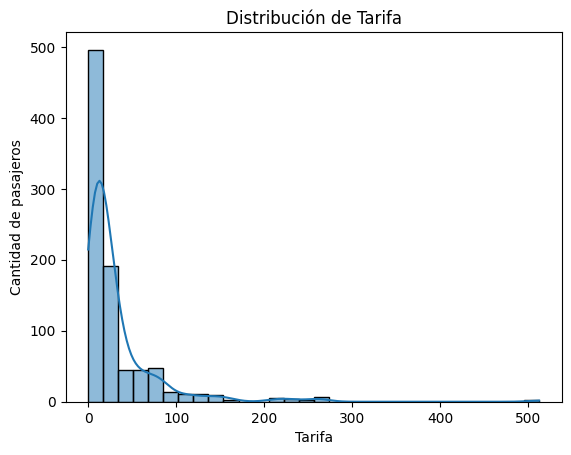

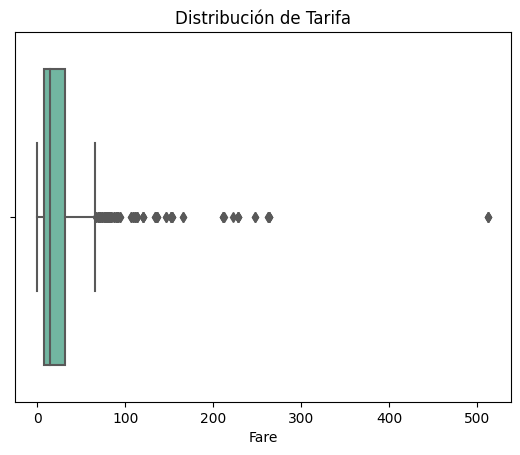

In [40]:
# Visualización de Fare

sns.histplot(df['Fare'], kde=True, bins=30, palette="Set2")
plt.title('Distribución de Tarifa') 
plt.xlabel('Tarifa')
plt.ylabel('Cantidad de pasajeros') 
plt.show()

sns.boxplot(x=df['Fare'], palette="Set2")
plt.title('Distribución de Tarifa')
plt.show()

In [75]:
def resumen_numericas_discretas (df, col):
    data = df[col]
    
    resumen = {
        "variable": col,
        "dtype": data.dtype,
        "n": data.shape[0],
        "nulos": data.isna().sum(),
        "% nulos": round(data.isna().mean() * 100, 2),
        "valores unicos": data.nunique(),
        "conteo valores unicos": round(data.value_counts(normalize=True), 2).to_dict(),
        "min": data.min(),
        "max": data.max(),
        "moda": data.mode().iloc[0],
        "media": data.mean(),
        "mediana": data.median(),
        "std": data.std(),
        "var": data.var()
    }
    
    return pd.DataFrame([resumen])

In [76]:
# SibSp validación Hermanos y cónyuges a bordo

resumen_numericas_discretas(df, 'SibSp')

,variable,dtype,n,nulos,% nulos,valores unicos,conteo valores unicos,min,max,moda,media,mediana,std,var
0,SibSp,int64,891,0,0.0,7,"{0: 0.68, 1: 0.23, 2: 0.03, 4: 0.02, 3: 0.02, ...",0,8,0,0.523008,0.0,1.102743,1.216043


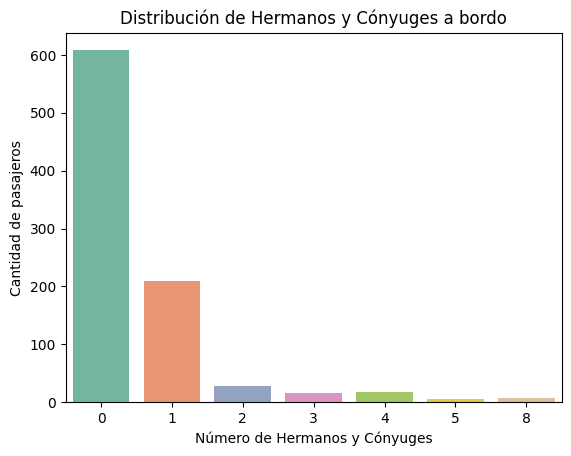

In [56]:
# Visualización de sibsp

sns.countplot(
    data=df,
    x='SibSp',
    palette='Set2')
plt.title('Distribución de Hermanos y Cónyuges a bordo')
plt.xlabel('Número de Hermanos y Cónyuges')
plt.ylabel('Cantidad de pasajeros')
plt.show()

In [64]:
# Parch validación Padres e hijos a bordo

resumen_numericas_discretas(df, 'Parch')

,variable,dtype,n,nulos,% nulos,valores unicos,conteo valores unicos,min,max,media,mediana,std,var
0,Parch,int64,891,0,0.0,7,"{0: 678, 1: 118, 2: 80, 5: 5, 3: 5, 4: 4, 6: 1}",0,6,0.381594,0.0,0.806057,0.649728
